## Random Forest Classification Predection


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.exceptions as px
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df =pd.read_csv('Travel.csv')

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning

### Handling the data 
1. Handle Missing Vlues
2. Handle Duplicates
3. Chek Data types
4. Understand The Data Set

In [4]:
# Chek the missing Values
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
# ✅ STEP 3: Chek  Mismatch values
print("\n🔍 CATEGORICAL COLUMNS UNIQUE VALUES:")
print("="*50)

for col in df.select_dtypes(include='object').columns: # only text data chek
    unique_vals = df[col].unique()
    print(f"\n✅ {col} ({len(unique_vals)} unique):") # len are use to count data 
    print(f"   {unique_vals}")


🔍 CATEGORICAL COLUMNS UNIQUE VALUES:

✅ TypeofContact (3 unique):
   <StringArray>
['Self Enquiry', 'Company Invited', nan]
Length: 3, dtype: str

✅ Occupation (4 unique):
   <StringArray>
['Salaried', 'Free Lancer', 'Small Business', 'Large Business']
Length: 4, dtype: str

✅ Gender (3 unique):
   <StringArray>
['Female', 'Male', 'Fe Male']
Length: 3, dtype: str

✅ ProductPitched (5 unique):
   <StringArray>
['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King']
Length: 5, dtype: str

✅ MaritalStatus (4 unique):
   <StringArray>
['Single', 'Divorced', 'Married', 'Unmarried']
Length: 4, dtype: str

✅ Designation (5 unique):
   <StringArray>
['Manager', 'Executive', 'Senior Manager', 'AVP', 'VP']
Length: 5, dtype: str


In [6]:
## Chek All Categrious
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [8]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
import numpy as np

feature_with_na = [feature for feature in df.columns if df[feature].isnull().sum() >=1]

for feature in feature_with_na:
    print(feature, np.round(df[feature].isnull().mean() * 100, 5), "% missing values")

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [11]:
## Statics on numerical Coloumns (Nulls col) only numerical data
df[feature_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null Values

#### Remember 
1.Text Column    →  mode()[0]            
2. Number+Outlier →  median()             
3. Count Column   →  0 (logical fill)     
4. Normal Number  →  mean()         

In [ ]:
## AGe
df['Age'] = df['Age'].fillna(df['Age'].median())

# TypeofContact
df['TypeofContact']=df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])

## DurationOfPitch
df['DurationOfPitch']=df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())

## NumberOfFollowups
df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0])

## PreferredPropertyStar
df['PreferredPropertyStar']=df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0])

## NumberOfTrips
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].median())

## NumberOfChildrenVisiting
df['NumberOfChildrenVisiting']=df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0])

## MonthlyIncome
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [13]:
df.head()
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [14]:
df.drop('CustomerID',inplace=True,axis=1)

## Feature Engineering

In [15]:
print(df.columns.tolist())

['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']


In [16]:
## Creat a New Coloumn For Feature Engineering
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],inplace=True)

In [17]:
print(df.columns.tolist())

['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome', 'TotalVisiting']


In [18]:
df['TotalVisiting']

0       3.0
1       5.0
2       3.0
3       3.0
4       2.0
       ... 
4883    4.0
4884    6.0
4885    7.0
4886    5.0
4887    6.0
Name: TotalVisiting, Length: 4888, dtype: float64

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   str    
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   str    
 6   Gender                  4888 non-null   str    
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   str    
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   str    
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   int64  
 15

In [20]:
# # # Numrical feature Alternative Method to Auto Selection


# num_feature = [feature for feature in 
#                df.select_dtypes(exclude='object').columns]
# print('Num of Numerical Features : ', len(num_feature))


In [21]:
# ## Get all Numeric Feature 
# num_feature = [feature for feature in df.columns if df[feature].dtype != 'int']
# print('Num of numerical Features : ',len(num_feature))

In [22]:
# ## Categrical Featurs
# cat_feature = [feature for feature in df.columns if df[feature].dtype == 'str']
# print('Num of Categrical Features : ',len(cat_feature))

In [23]:
# ## For Discreate Feature
# discreate_feature = [feature for feature in df.columns if len(df[feature].unique())<=25]
# print('Num of discreate Features : ',len(discreate_feature))

In [24]:
# # for continueous_feature
# continueous_feature = [feature for feature in num_feature if feature not in discreate_feature]
# print('Num of continoues Features : ',len(continueous_feature))

In [25]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


## Model Selection to 

In [26]:
from sklearn.model_selection import train_test_split
X = df.drop('ProdTaken', axis=1)   # Features
y = df['ProdTaken']                # Target


In [27]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [28]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [29]:
# Now i will train test spliting
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((3910, 17), (978, 17))

In [ ]:
## crat Coloumn Transform With 3 types of transforms
cat_feature = X.select_dtypes(include='object').columns  #  Selecting  Text columns
num_feature = X.select_dtypes(include='number').columns  # Selecting Number columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler 
from sklearn.compose import ColumnTransformer

numeric_transform =StandardScaler()
oh_transform = OneHotEncoder(drop='first') # Text → 0/1 

preprocess = ColumnTransformer (
    [
        ("OneHotEncoder",oh_transform,cat_feature),
        ("StandardScaler",numeric_transform ,num_feature)
    ]
)

In [31]:
print(preprocess)

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='str')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='str'))])


## Remeber Always to
1. When use standscaler,onehotencoder so use always :
             
             scaler.fit_transform(X_train) use fit_transform

2. when use Model train like logistic,regrssion,linnerregression :

            model.fit(X_train, y_train)      as like this code use        

In [32]:
X_train  = preprocess.fit_transform(X_train)

In [33]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [34]:
X_test = preprocess.transform(X_test)

In [35]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,-0.287333,1.284279,-0.725271,-1.220627,-0.632399,-0.777720,-1.277194,-0.737510,-0.774151
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.366823,-0.531672,0.282777,0.522885,-1.220627,1.581280,1.408395,-1.277194,-0.670411,-0.065268
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,0.812193,0.282777,-0.725271,0.965153,-0.632399,1.408395,0.782966,-0.420832,-0.774151
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.721400,2.522566,2.285781,-0.725271,1.511598,-0.632399,-0.049015,0.782966,-0.113658,0.643615
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,-1.020350,0.282777,0.522885,-0.127737,1.581280,0.679690,0.782966,-0.317047,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,-0.725271,1.511598,-0.632399,1.408395,0.782966,0.498219,0.643615
974,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.142519,0.282777,1.771041,-0.674182,1.581280,-1.506426,-1.277194,-1.184015,-1.483035
975,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,1.056532,1.284279,-0.725271,-0.674182,1.581280,1.408395,0.782966,0.690012,0.643615
976,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.287333,-2.721728,-0.725271,-0.674182,-0.632399,1.408395,0.782966,-0.228278,-0.774151


## Randoom Forest Classifire Training

In [36]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  confusion_matrix,classification_report,accuracy_score,precision_score,\
                                            f1_score,ConfusionMatrixDisplay,roc_auc_score,roc_curve,recall_score

In [37]:
models = {
    #   KEY (Naam)      VALUE (Object)
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(max_depth=5),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier()
    #  "Decision Tree" : DecisionTreeClassifier(),
}

for i in range(len(list(models))): # to get model
    model = list(models.values())[i] # to ask model name
    model.fit(X_train,y_train) 

    ## MAke Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    ## Training set performace
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_roc = roc_auc_score(y_train,y_train_pred)

    ## Test set performance 
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_roc = roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i]) # Model  name prnints
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_roc))



    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_roc))

    print('='*35)
    print('\n')


Logisitic Regression
Model performance for Training set
- Accuracy: 0.8460
- F1 score: 0.8202
- Precision: 0.7016
- Recall: 0.3032
- Roc Auc Score: 0.6368
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.8087
- Precision: 0.6914
- Recall: 0.2932
- Roc Auc Score: 0.6307


Decision Tree
Model performance for Training set
- Accuracy: 0.8621
- F1 score: 0.8433
- Precision: 0.7568
- Recall: 0.3841
- Roc Auc Score: 0.6779
----------------------------------
Model performance for Test set
- Accuracy: 0.8507
- F1 score: 0.8351
- Precision: 0.6991
- Recall: 0.4136
- Roc Auc Score: 0.6852


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9284
- F1 score: 0.9228
- Precision: 0.9690
- Recall: 0.6545
- Roc Auc Score: 0.8247


Gradient Boost
Model performance for Training se

## Now be Hyperperameter Tunning

In [38]:
rf_parmas = {
    'max_depth': [5,8,15,None,10],
    'max_features':[5,7,'auto',8],
    'min_samples_split':[2,8,15,20],
    'n_estimators':[100,200,500,1000]

}

In [39]:
# # Ye tumhare code mein missing hai!
# # Pehle ye banana padega

# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.linear_model import LogisticRegression

# random_cv_models = [
# #   (Name,           Model,                    Parameters)
#     (
#         "Logistic Regression",
#         LogisticRegression(),
#         {
#             'C': [0.001, 0.01, 0.1, 1, 10, 100],
#             'penalty': ['l1', 'l2'],
#             'solver': ['liblinear', 'saga']
#         }
#     ),
#     (
#         "Decision Tree",
#         DecisionTreeClassifier(),
#         {
#             'max_depth': [3, 5, 7, 10, None],
#             'min_samples_split': [2, 5, 10, 20],
#             'min_samples_leaf': [1, 2, 4, 6],
#             'criterion': ['gini', 'entropy']
#         }
#     ),
#     (
#         "Random Forest",
#         RandomForestClassifier(),
#         {
#             'n_estimators': [100, 200, 300],
#             'max_depth': [3, 5, 7, 10, None],
#             'min_samples_split': [2, 5, 10],
#             'min_samples_leaf': [1, 2, 4]
#         }
#     ),
#     (
#         "Gradient Boost",
#         GradientBoostingClassifier(),
#         {
#             'n_estimators': [100, 200, 300],
#             'learning_rate': [0.01, 0.05, 0.1, 0.2],
#             'max_depth': [3, 5, 7],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     )
# ]

In [40]:
## Model list for hyperameter tuning
random_cv_models = [
    ("RF", RandomForestClassifier(),rf_parmas)
]

In [41]:
from sklearn.model_selection import RandomizedSearchCV ## Best parmater findig to us

model_param ={}
for name,model, params in random_cv_models:
    random =RandomizedSearchCV(estimator=model, # which model can be  use
                                   param_distributions=params,
                                   n_iter=100, # how much random combination chek 
                                   cv=3,
                                   verbose=2, # How much Output show
                                   n_jobs=-1) # How Much Cpu are use here all
     
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=15, max_features=8, min_samples_split=8, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, max_features=8, min_samples_split=8, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=8, min_samples_split=8, n_estimators=200; total time=   0.7s
[CV] END max_depth=15, max_features=8, min_samples_split=8, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=8, min_samples_split=15, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=8, min_samples_split=15, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=8, min_samples_split=15, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=8, min_samples_split=8, n_estimators=200; total time=   0.8s
[CV] END max_depth=None, max_features=8, min_samples_split=8, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=5, min_samp

In [42]:
models ={
    "Random Forest":RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                           max_features=8,max_depth=None)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9346
- F1 score: 0.9305
- Precision: 0.9568
- Recall: 0.6963
- Roc Auc Score: 0.8444




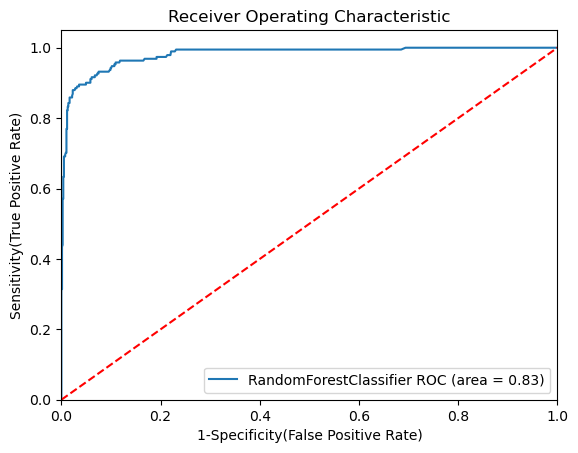

In [43]:
## Plot the Roc & Auc Curv
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC 

auc_models = [
 {   'label':'RandomForestClassifier',
    'model':RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                           max_features=8,max_depth=None),
    'auc':0.8319
 },
]

# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model

# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1]) #Positive class's probability chek

# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))

# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 